# Path Generation code (4.1.1)



In [1]:
# Code development statement:

# Generative AI tools were used for assistance,

# code refinement and improving comments.

# All algorithms were independently reviewed, tested, and modified

# by the author to ensure correctness and understanding.
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

from image_processing import (
    load_and_process_image,
    process_image,
    split_into_cells,
    detect_maze_walls,
    synchronise_walls,
    display_occupancy_map,
    make_cells_black
)

from graph import (
    create_grid_graph
)

random.seed(42)

seed = 42
image_file = "./maze_images/amir_photo.jpg"

# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

# Task 3 - BFS
bfs_n = 9
bfs_start_node = 10
bfs_end_node = 70


In [2]:
def create_obstacle_occupancy_map(
        binary_image,
        graph,
        rows=9,
        cols=9,
        top_left=(2, 0),
        obstacle_cells=5,
        obstacle_buffer=40,
        wall_buffer=45,
        min_area=500,
        edge_margin=50,          
        output_size=900
):
    """
    Create occupancy map for the fixed 5x5 obstacle area.

    Image:
        1620 x 1620 pixels
        1 pixel = 1 mm

    Obstacle area:
        5 x 5 cells
        top-left cell = (3, 1)

    Obstacles:
        Black regions
        Components smaller than min_area are removed.

    obstacle_buffer:
        40 pixels

    wall_buffer:
        45 pixels

    Output:
        900 x 900 binary occupancy map
        0 = free
        1 = occupied
    """

    # =========================================================
    # 1. Image dimensions
    # =========================================================

    image_height, image_width = binary_image.shape[:2]

    cell_width = image_width / cols
    cell_height = image_height / rows

    # =========================================================
    # 2. Extract 5x5 obstacle area
    # =========================================================

    start_col = top_left[0]
    start_row = top_left[1]

    end_col = start_col + obstacle_cells
    end_row = start_row + obstacle_cells

    x_start = int(round(start_col * cell_width))
    x_end = int(round(end_col * cell_width))

    y_start = int(round(start_row * cell_height))
    y_end = int(round(end_row * cell_height))

    obstacle_area = binary_image[
        y_start:y_end,
        x_start:x_end
    ]

    print(
        "\nObstacle area:",
        obstacle_area.shape[1],
        "x",
        obstacle_area.shape[0],
        "pixels"
    )

    # =========================================================
    # 3. Create black-pixel mask
    # =========================================================

    black_mask = np.zeros_like(
        obstacle_area,
        dtype=np.uint8
    )

    black_mask[
        obstacle_area < 128
    ] = 255

    # =========================================================
    # 4. Connected-component analysis
    # =========================================================

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        black_mask,
        connectivity=8
    )

    filtered_mask = np.zeros_like(
        black_mask,
        dtype=np.uint8
    )

    area_height, area_width = black_mask.shape[:2]

    print("\nDetected black regions:")

    for label in range(1, num_labels):

        area = stats[label, cv2.CC_STAT_AREA]
        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]
        width = stats[label, cv2.CC_STAT_WIDTH]
        height = stats[label, cv2.CC_STAT_HEIGHT]

        print(
            f"Region {label}: "
            f"area = {area} px², "
            f"bbox = ({x}, {y}, {width}, {height})"
        )

        # =====================================================
        # Remove anything smaller than min_area
        # =====================================================
        if area < min_area:
            print(f"    -> REMOVED (area < {min_area} px²)")
            continue

        # =====================================================
        # Remove anything within edge_margin px of any border
        # =====================================================
        x_end = x + width
        y_end = y + height

        touches_edge = (
            x < edge_margin or
            y < edge_margin or
            (area_width - x_end) < edge_margin or
            (area_height - y_end) < edge_margin
        )

        if touches_edge:
            print(f"    -> REMOVED (within {edge_margin}px of edge)")
            continue

        print("    -> KEPT")

        filtered_mask[labels == label] = 255

    # =========================================================
    # 5. Create occupancy map from filtered obstacles
    # =========================================================

    occupancy_map = np.zeros_like(
        filtered_mask,
        dtype=np.uint8
    )

    occupancy_map[
        filtered_mask > 0
    ] = 1

    # =========================================================
    # 6. Buffer ONLY the valid obstacles
    # =========================================================

    if obstacle_buffer > 0:

        kernel_size = (
            2 * obstacle_buffer + 1
        )

        obstacle_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                kernel_size,
                kernel_size
            )
        )

        occupancy_map = cv2.dilate(
            occupancy_map,
            obstacle_kernel
        )

    # =========================================================
    # 7. Create wall mask
    # =========================================================

    wall_mask = np.zeros_like(
        occupancy_map,
        dtype=np.uint8
    )

    local_cell_width = (
        occupancy_map.shape[1]
        / obstacle_cells
    )

    local_cell_height = (
        occupancy_map.shape[0]
        / obstacle_cells
    )

    # =========================================================
    # LEFT wall
    # =========================================================

    left_column = start_col - 1

    if left_column >= 0:

        for r in range(
            start_row,
            start_row + obstacle_cells
        ):

            node_id = (
                r * cols + left_column
            )

            node = graph.nodes[node_id]

            if node.east:

                local_row = r - start_row

                y0 = int(
                    round(
                        local_row *
                        local_cell_height
                    )
                )

                y1 = int(
                    round(
                        (local_row + 1) *
                        local_cell_height
                    )
                )

                wall_mask[
                    y0:y1,
                    :
                ][:, :5] = 1

    # =========================================================
    # RIGHT wall
    # =========================================================

    right_column = (
        start_col + obstacle_cells
    )

    if right_column < cols:

        for r in range(
            start_row,
            start_row + obstacle_cells
        ):

            node_id = (
                r * cols + right_column
            )

            node = graph.nodes[node_id]

            if node.west:

                local_row = r - start_row

                y0 = int(
                    round(
                        local_row *
                        local_cell_height
                    )
                )

                y1 = int(
                    round(
                        (local_row + 1) *
                        local_cell_height
                    )
                )

                wall_mask[
                    y0:y1,
                    -5:
                ] = 1

    # =========================================================
    # TOP wall
    # =========================================================

    top_row = start_row - 1

    if top_row >= 0:

        for c in range(
            start_col,
            start_col + obstacle_cells
        ):

            node_id = (
                top_row * cols + c
            )

            node = graph.nodes[node_id]

            if node.south:

                local_col = c - start_col

                x0 = int(
                    round(
                        local_col *
                        local_cell_width
                    )
                )

                x1 = int(
                    round(
                        (local_col + 1) *
                        local_cell_width
                    )
                )

                wall_mask[
                    :5,
                    x0:x1
                ] = 1

    # =========================================================
    # BOTTOM wall
    # =========================================================

    bottom_row = (
        start_row + obstacle_cells
    )

    if bottom_row < rows:

        for c in range(
            start_col,
            start_col + obstacle_cells
        ):

            node_id = (
                bottom_row * cols + c
            )

            node = graph.nodes[node_id]

            if node.north:

                local_col = c - start_col

                x0 = int(
                    round(
                        local_col *
                        local_cell_width
                    )
                )

                x1 = int(
                    round(
                        (local_col + 1) *
                        local_cell_width
                    )
                )

                wall_mask[
                    -5:,
                    x0:x1
                ] = 1

    # =========================================================
    # 8. Buffer walls by 45 pixels
    # =========================================================

    if wall_buffer > 0:

        wall_kernel_size = (
            2 * wall_buffer + 1
        )

        wall_kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (
                wall_kernel_size,
                wall_kernel_size
            )
        )

        wall_mask = cv2.dilate(
            wall_mask,
            wall_kernel
        )

    # =========================================================
    # 9. Combine obstacles + walls
    # =========================================================

    occupancy_map = np.maximum(
        occupancy_map,
        wall_mask
    )

    # =========================================================
    # 10. Resize if necessary
    # =========================================================

    if occupancy_map.shape != (
        output_size,
        output_size
    ):

        occupancy_map = cv2.resize(
            occupancy_map,
            (
                output_size,
                output_size
            ),
            interpolation=cv2.INTER_NEAREST
        )

    # =========================================================
    # 11. Make absolutely sure output is binary
    # =========================================================

    occupancy_map = (
        occupancy_map > 0
    ).astype(np.uint8)

    # =========================================================
    # 12. Print statistics
    # =========================================================

    print(
        "\nFinal occupancy map:"
    )

    print(
        "Size:",
        occupancy_map.shape[1],
        "x",
        occupancy_map.shape[0]
    )

    print(
        "Occupied pixels:",
        np.sum(occupancy_map == 1)
    )

    print(
        "Free pixels:",
        np.sum(occupancy_map == 0)
    )

    return occupancy_map

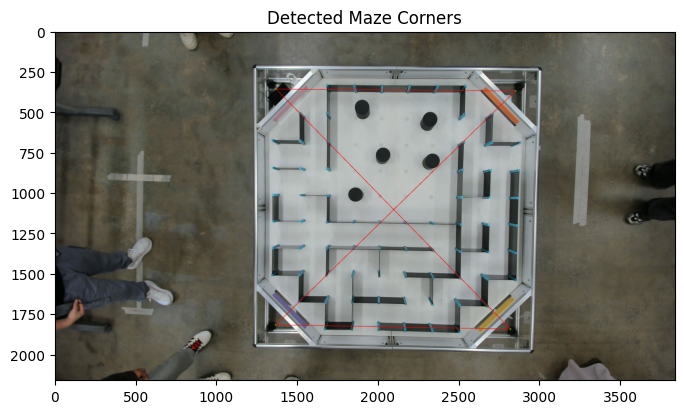

Image size: 1620 x 1620
Cell size: 180 x 180


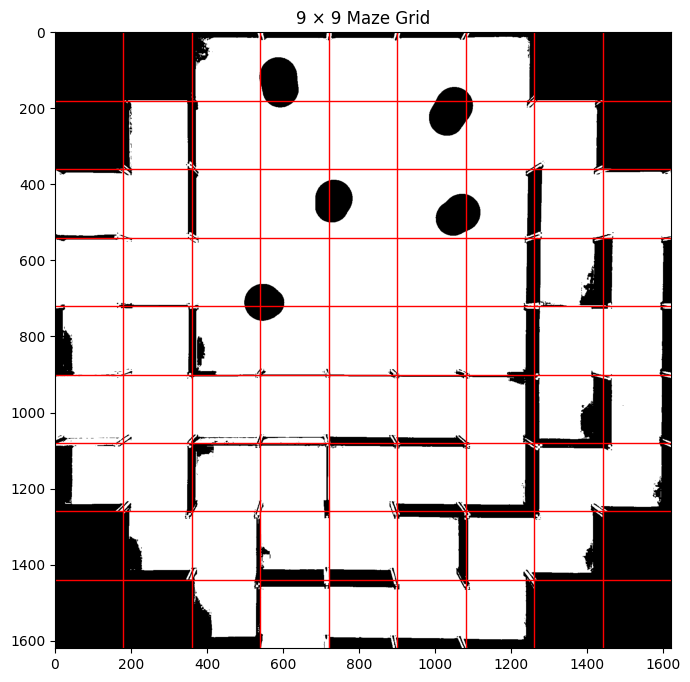


Obstacle area: 900 x 900 pixels

Detected black regions:
Region 1: area = 8026 px², bbox = (0, 0, 176, 357)
    -> KEPT
Region 2: area = 75 px², bbox = (178, 0, 9, 22)
    -> REMOVED (area < 500 px²)
Region 3: area = 2682 px², bbox = (187, 0, 168, 21)
    -> KEPT
Region 4: area = 2659 px², bbox = (367, 0, 168, 18)
    -> KEPT
Region 5: area = 89 px², bbox = (534, 0, 10, 23)
    -> REMOVED (area < 500 px²)
Region 6: area = 2693 px², bbox = (546, 0, 172, 21)
    -> KEPT
Region 7: area = 89 px², bbox = (712, 0, 15, 21)
    -> REMOVED (area < 500 px²)
Region 8: area = 4483 px², bbox = (725, 0, 175, 196)
    -> KEPT
Region 9: area = 41 px², bbox = (358, 11, 5, 12)
    -> REMOVED (area < 500 px²)
Region 10: area = 1 px², bbox = (529, 18, 1, 1)
    -> REMOVED (area < 500 px²)
Region 11: area = 2 px², bbox = (353, 20, 2, 1)
    -> REMOVED (area < 500 px²)
Region 12: area = 1 px², bbox = (367, 20, 1, 1)
    -> REMOVED (area < 500 px²)
Region 13: area = 1 px², bbox = (36, 22, 1, 1)
    -> REMOV

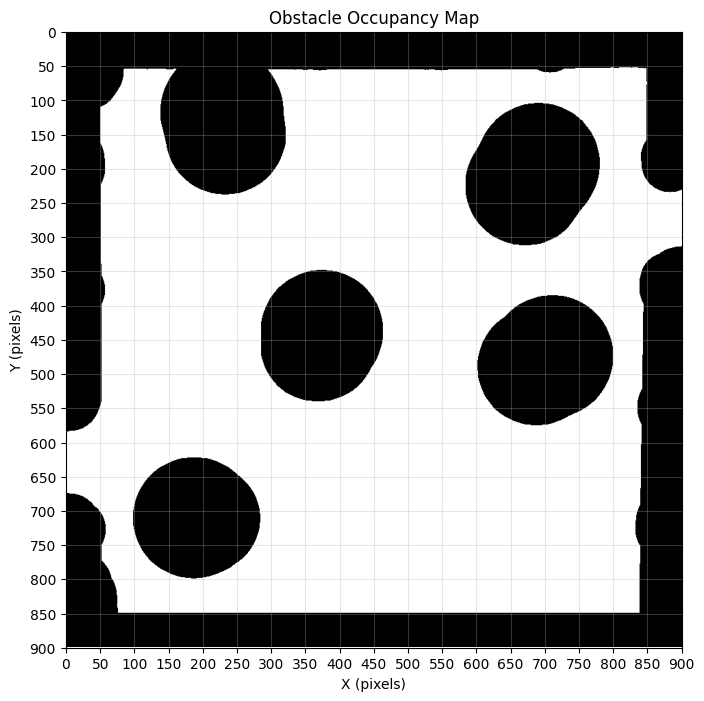

In [3]:
def main():

    # ---------------------------------------------------------
    # 1. Load and process image
    # ---------------------------------------------------------

    binary, transformed_image = load_and_process_image(
        image_file
    )

    # ---------------------------------------------------------
    # 2. Ignore unwanted outer cells
    # ---------------------------------------------------------

    black_cells = [
        0, 1, 7, 8,
        9, 17,
        63, 71,
        72, 73, 79, 80
    ]

    binary = make_cells_black(
        binary,
        black_cells,
        bfs_n,
        bfs_n
    )

    # ---------------------------------------------------------
    # 3. Divide image into cells
    # ---------------------------------------------------------

    cells, cell_width, cell_height = split_into_cells(
        binary,
        bfs_n
    )

    print(
        "Image size:",
        binary.shape[1],
        "x",
        binary.shape[0]
    )

    print(
        "Cell size:",
        cell_width,
        "x",
        cell_height
    )

    # ---------------------------------------------------------
    # 4. Display processed binary maze
    # ---------------------------------------------------------

    display_occupancy_map(
        binary,
        cell_width,
        cell_height,
        bfs_n
    )

    # ---------------------------------------------------------
    # 5. Detect maze walls
    # ---------------------------------------------------------

    maze = detect_maze_walls(
        cells,
        bfs_n
    )

    # ---------------------------------------------------------
    # 6. Create graph
    #
    # (Only required because the occupancy-map function
    # uses the wall information stored in the graph.)
    # ---------------------------------------------------------

    graph = create_grid_graph(
        bfs_n
    )

    synchronise_walls(
        graph,
        maze,
        bfs_n
    )

    # ---------------------------------------------------------
    # 7. Create obstacle occupancy map
    # ---------------------------------------------------------

    
    occupancy_map = create_obstacle_occupancy_map(
        binary_image=binary,
        graph=graph,
        rows=bfs_n,
        cols=bfs_n,
        top_left=(2, 0),
        obstacle_cells=5,
        obstacle_buffer=40,
        wall_buffer=45,
        min_area=500,
        edge_margin=0,
        output_size=900
    )

    # ---------------------------------------------------------
    # 8. Display occupancy map
    # ---------------------------------------------------------

    print(
        "\nOccupancy map size:",
        occupancy_map.shape[1],
        "x",
        occupancy_map.shape[0],
        "pixels"
    )

    plt.figure(figsize=(8, 8))

    plt.imshow(
        occupancy_map,
        cmap="gray_r",
        origin="upper"
    )

    plt.title("Obstacle Occupancy Map")

    plt.xlabel("X (pixels)")
    plt.ylabel("Y (pixels)")

    plt.xticks(
        np.arange(
            0,
            occupancy_map.shape[1] + 1,
            50
        )
    )

    plt.yticks(
        np.arange(
            0,
            occupancy_map.shape[0] + 1,
            50
        )
    )

    plt.grid(True, alpha=0.3)

    plt.show()


if __name__ == "__main__":
    main()